## Countries life expectancy

https://www.kaggle.com/datasets/saurabhbadole/life-expectancy-based-on-geographic-locations

In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import KNNImputer

## Exploratory data analysis

In [291]:
def plot_timeline_per_country(data, countries_list, column_name):
    fig, ax = plt.subplots(figsize=(10, 5))
    for country in countries_list:
        data_country = data[data.Country == country]
        ax.plot(data_country.Year, data_country[column_name], label=country)
    ax.set_xticks(data.Year.unique())
    ax.grid()
    ax.legend()
    return fig, ax

In [292]:
data = pd.read_csv("../datasets/LifeExpectancy.csv")
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [293]:
data["Country"].value_counts().describe()

count    183.0
mean      16.0
std        0.0
min       16.0
25%       16.0
50%       16.0
75%       16.0
max       16.0
Name: count, dtype: float64

In [294]:
data.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2928.00000,2928.000000,2928.000000,2928.000000,2735.000000,2928.000000,2375.000000,2928.000000,2896.000000,2928.000000,2909.000000,2702.000000,2909.000000,2928.000000,2485.000000,2.284000e+03,2896.000000,2896.000000,2768.000000,2768.000000
mean,2007.50000,69.224932,164.796448,30.407445,4.614856,740.321185,80.960842,2427.855874,38.235394,42.179303,82.548298,5.930163,82.321416,1.747712,7494.210719,1.276454e+07,4.850622,4.881423,0.627419,11.999639
std,4.61056,9.523867,124.292079,118.114450,4.050749,1990.930605,25.018337,11485.970937,19.959590,160.700547,23.416674,2.483273,23.706644,5.085542,14282.251492,6.103765e+07,4.420829,4.509609,0.210978,3.346440
min,2000.00000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2003.75000,63.100000,74.000000,0.000000,0.905000,4.853964,77.000000,0.000000,19.300000,0.000000,78.000000,4.260000,78.000000,0.100000,463.852618,1.966738e+05,1.600000,1.575000,0.493000,10.100000
50%,2007.50000,72.100000,144.000000,3.000000,3.770000,65.611455,92.000000,17.000000,43.350000,4.000000,93.000000,5.750000,93.000000,0.100000,1764.973870,1.391756e+06,3.300000,3.400000,0.677000,12.300000
75%,2011.25000,75.700000,228.000000,22.000000,7.715000,442.614322,97.000000,362.250000,56.100000,28.000000,97.000000,7.490000,97.000000,0.800000,5932.899677,7.426746e+06,7.200000,7.200000,0.779250,14.300000
max,2015.00000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,77.600000,2500.000000,99.000000,17.600000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [295]:
#data = data.drop(columns=["Country", "Status"])
data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


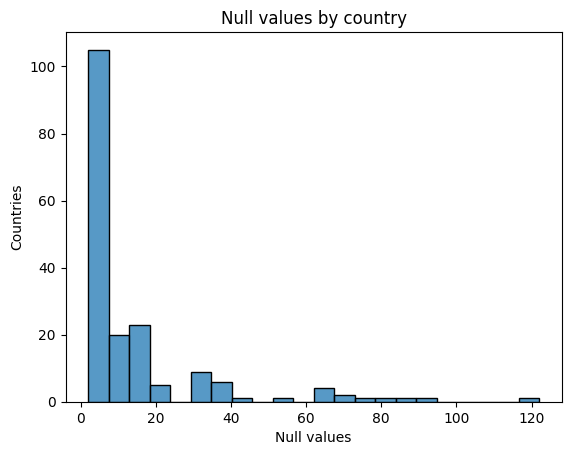

In [296]:
data["null_values"] = data.isna().sum(axis = 1)
null_values_by_country = data.groupby("Country")["null_values"].sum()
axes = sns.histplot(null_values_by_country[null_values_by_country > 0])
axes.set_xlabel("Null values")
axes.set_ylabel("Countries")
axes.set_title("Null values by country")
plt.show()

In [297]:
null_values_by_country.sort_values(ascending=False)

Country
South Sudan                                             122
Somalia                                                  91
Democratic People's Republic of Korea                    84
United Kingdom of Great Britain and Northern Ireland     81
Democratic Republic of the Congo                         73
                                                       ... 
Ukraine                                                   2
Vanuatu                                                   2
Zimbabwe                                                  2
Afghanistan                                               0
Albania                                                   0
Name: null_values, Length: 183, dtype: int64

In [298]:
null_columns = data.isna().sum()
null_columns

Country                              0
Year                                 0
Status                               0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                            193
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                32
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                443
Population                         644
 thinness  1-19 years               32
 thinness 5-9 years                 32
Income composition of resources    160
Schooling                          160
null_values                          0
dtype: int64

In [299]:
data.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling', 'null_values'],
      dtype='object')

In [300]:
for col in null_columns.index:
    if null_columns[col] > 0:
        print(col, null_columns[col], "Null values")
        display(pd.DataFrame(data[data[col].isna()].Country.value_counts()))

Alcohol 193 Null values


,count
Country,
South Sudan,16
Montenegro,2
Antigua and Barbuda,1
Angola,1
Armenia,1
...,...
Venezuela (Bolivarian Republic of),1
Viet Nam,1
Yemen,1


Hepatitis B 553 Null values


,count
Country,
Finland,16
Denmark,16
Norway,16
Slovenia,16
United Kingdom of Great Britain and Northern Ireland,16
...,...
Guyana,1
Mozambique,1
Grenada,1


 BMI  32 Null values


...

,count
Country,
South Sudan,16
Sudan,16


Income composition of resources 160 Null values


,count
Country,
Côte d'Ivoire,16
Czechia,16
Democratic People's Republic of Korea,16
Democratic Republic of the Congo,16
Republic of Korea,16
Republic of Moldova,16
Somalia,16
United Kingdom of Great Britain and Northern Ireland,16
United Republic of Tanzania,16


Schooling 160 Null values


,count
Country,
Côte d'Ivoire,16
Czechia,16
Democratic People's Republic of Korea,16
Democratic Republic of the Congo,16
Republic of Korea,16
Republic of Moldova,16
Somalia,16
United Kingdom of Great Britain and Northern Ireland,16
United Republic of Tanzania,16


We are going to drop some problematic rows and columns

In [301]:
data = data[~data.Country.isin(["South Sudan","Democratic People's Republic of Korea", "Somalia", "Sudan"])].reset_index()
#data = data.drop(columns=["GDP", "Population", "Income composition of resources", "Schooling"])
data

,index,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,null_values
0,0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,0
1,1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,0
2,2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,0
3,3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,0
4,4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,...,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,0
2860,2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,...,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,0
2861,2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,...,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,0
2862,2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,...,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,0



## Working with Nulls

Lets solve null values step by step

### Alcohol

In [302]:
country_year_alcohol = data[["Country", "Year", "Alcohol"]]
country_year_alcohol[country_year_alcohol.Alcohol.isna()].Year.value_counts()

Year
2015    173
2005      1
Name: count, dtype: int64

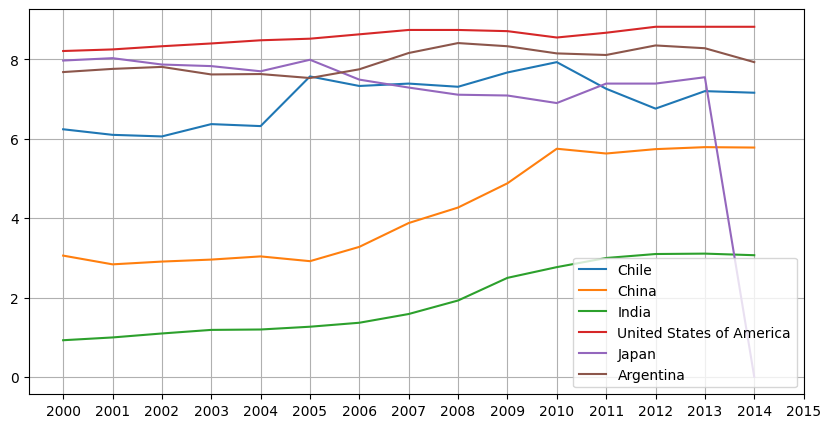

In [303]:
fig, axes = plot_timeline_per_country(data,
    ["Chile", "China", "India", "United States of America", "Japan", "Argentina"],
    "Alcohol")
plt.show()

In [304]:
for country in data.Country.unique():
    if data[data.Country == country].Alcohol.isna().sum() > 0:
        data_country = data[data.Country == country].sort_values(by="Year")
        data_country_last = data_country[data_country.Year.isin([2012, 2013, 2014])]
        imputed_alcohol = data_country_last.Alcohol.mean()
        data.loc[(data.Year == 2015) & (data.Country == country), "Alcohol"] = imputed_alcohol
imputed_alcohol = data[(data.Country == "Montenegro") & (data.Year.isin([2004, 2006]))].Alcohol.mean()
data.loc[(data.Country == "Montenegro") & (data.Year == 2005), "Alcohol"] = imputed_alcohol
data

,index,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,null_values
0,0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,0
1,1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,0
2,2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,0
3,3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,0
4,4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,...,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,0
2860,2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,...,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,0
2861,2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,...,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,0
2862,2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,...,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,0


And we solved alcohol issue

In [305]:
country_year_alcohol = data[["Country", "Year", "Alcohol"]]
country_year_alcohol[country_year_alcohol.Alcohol.isna()].Year.value_counts()

Series([], Name: count, dtype: int64)

### Hepatitis B

In [306]:
nulls_hepatitis = data[["Country", "Year", "Hepatitis B"]][data["Hepatitis B"].isna()].Country.value_counts()

In [307]:
nulls_hepatitis[nulls_hepatitis == 16]

Country
Denmark                                                 16
Switzerland                                             16
Japan                                                   16
Iceland                                                 16
Hungary                                                 16
Finland                                                 16
Norway                                                  16
Slovenia                                                16
United Kingdom of Great Britain and Northern Ireland    16
Name: count, dtype: int64

If we look to the countries with 16 null values, those are developed countries. Probably they has 100% of immunized population.

We will assign 100 to those null values. 

In [308]:
immune_hepa_b_countries = nulls_hepatitis[nulls_hepatitis == 16].index.unique()
data.loc[data.Country.isin(immune_hepa_b_countries), "Hepatitis B"] = 100
data

,index,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,null_values
0,0,Afghanistan,2015,Developing,65.0,263,62,0.01,71.279624,65.0,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,0
1,1,Afghanistan,2014,Developing,59.9,271,64,0.01,73.523582,62.0,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,0
2,2,Afghanistan,2013,Developing,59.9,268,66,0.01,73.219243,64.0,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,0
3,3,Afghanistan,2012,Developing,59.5,272,69,0.01,78.184215,67.0,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,0
4,4,Afghanistan,2011,Developing,59.2,275,71,0.01,7.097109,68.0,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,2923,Zimbabwe,2004,Developing,44.3,723,27,4.36,0.000000,68.0,...,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2,0
2860,2924,Zimbabwe,2003,Developing,44.5,715,26,4.06,0.000000,7.0,...,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5,0
2861,2925,Zimbabwe,2002,Developing,44.8,73,25,4.43,0.000000,73.0,...,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0,0
2862,2926,Zimbabwe,2001,Developing,45.3,686,25,1.72,0.000000,76.0,...,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8,0


In [309]:
data[data.Country.isin(nulls_hepatitis[nulls_hepatitis < 16].index)].Country.unique()

array(['Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina',
       'Australia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados',
       'Benin', 'Bosnia and Herzegovina', 'Burkina Faso', 'Burundi',
       "Côte d'Ivoire", 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'Comoros', 'Congo',
       'Croatia', 'Czechia', 'Democratic Republic of the Congo',
       'Djibouti', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Ethiopia',
       'Gabon', 'Ghana', 'Grenada', 'Guatemala', 'Guinea',
       'Guinea-Bissau', 'Guyana', 'Haiti', 'India', 'Ireland', 'Jamaica',
       'Kenya', "Lao People's Democratic Republic", 'Lesotho', 'Liberia',
       'Madagascar', 'Malawi', 'Mali', 'Malta', 'Mauritania',
       'Montenegro', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal',
       'Netherlands', 'Niger', 'Nigeria', 'Pakistan', 'Panama',
       'Paraguay', 'Peru', 'Russian Federation', 'Rwanda', 'Saint Lucia',
       'Saint Vincent and the Grenadines

In [310]:
def interpolation(data, column_to_interpolate, zero_year = None):
    country_nulls = data[["Country", "Year", column_to_interpolate]][data[column_to_interpolate].isna()]
    for country in country_nulls.Country.unique():
        data_country = data[data.Country == country]
        data_to_train = data_country[data_country[column_to_interpolate].notna()][["Year", column_to_interpolate]]

        if zero_year is not None:
            new_row = pd.DataFrame({"Year": range(zero_year - 15, zero_year)})
            new_row[column_to_interpolate] = 0
            data_to_train = pd.concat([data_to_train, new_row], ignore_index=True)
        X, y = data_to_train[["Year"]], data_to_train[column_to_interpolate]
        pipeline = Pipeline(
            [("scaler", StandardScaler()), ("poly", PolynomialFeatures(degree=3)), ("model", Ridge())]
        )

        pipeline.fit(X, y)
        
        interpolated = pipeline.predict(
            data[(data["Country"] == country)][["Year"]])
        interpolated = np.clip(interpolated, 0, 100)

        data.loc[(data["Country"] == country), "interpolated"] = interpolated
        data.loc[(data[column_to_interpolate].isna()), column_to_interpolate] = data[
            data[column_to_interpolate].isna()]["interpolated"].round(2)
        data = data.drop(columns=["interpolated"])
    return data

In [311]:
def process_column(data, countries, column, zero_year = None, drop_less_10 = False):
    fig, axes = plot_timeline_per_country(data,
        countries,
        column)
    axes.set_title(f"{column} pre correction")
    plt.show()
    if drop_less_10:
        data.loc[data[column] < 10, column] = np.nan

    data = interpolation(data, column, zero_year)
    fig, axes = plot_timeline_per_country(data,
        countries,
        column)
    axes.set_title(f"{column} post correction")
    plt.show()
    return data


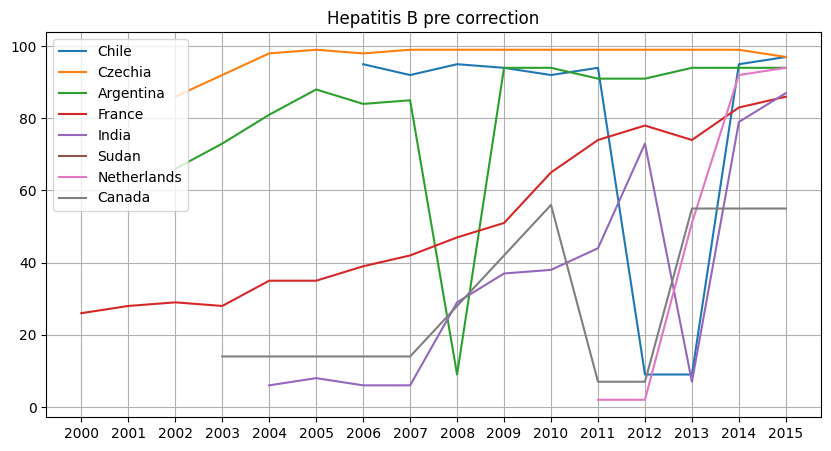

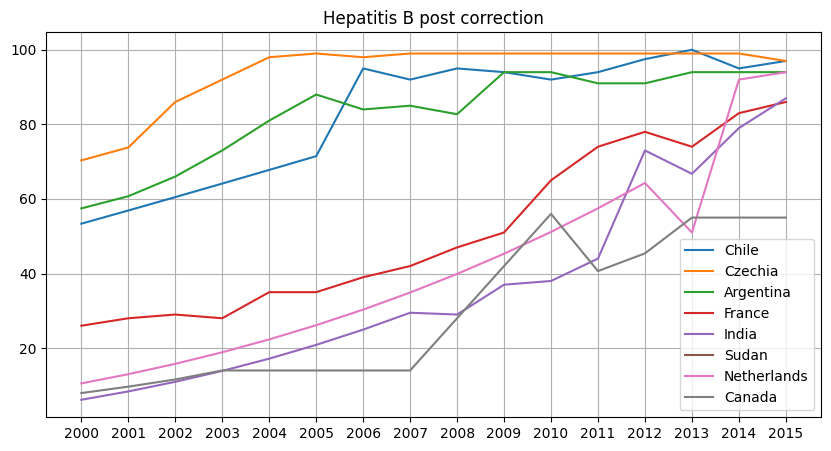

In [312]:
countries = ["Chile", "Czechia", "Argentina", "France", "India", "Sudan", "Netherlands", "Canada"]
data = process_column(data,
    countries,
    "Hepatitis B",
    zero_year = 1986,
    drop_less_10 = True)

### Polio

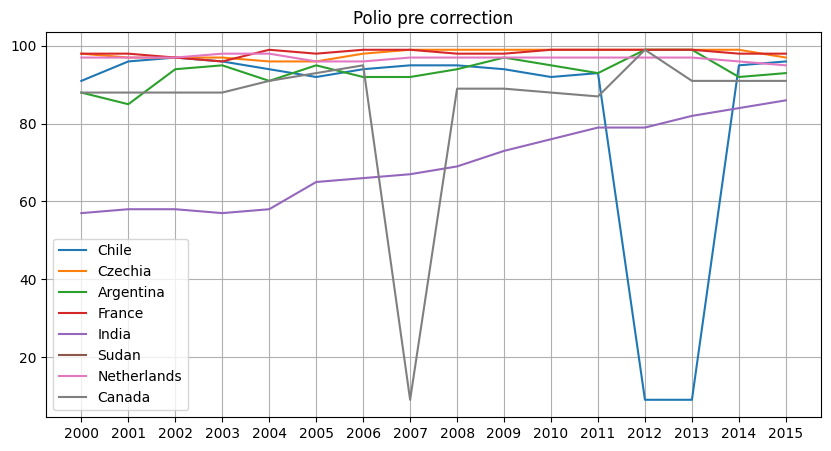

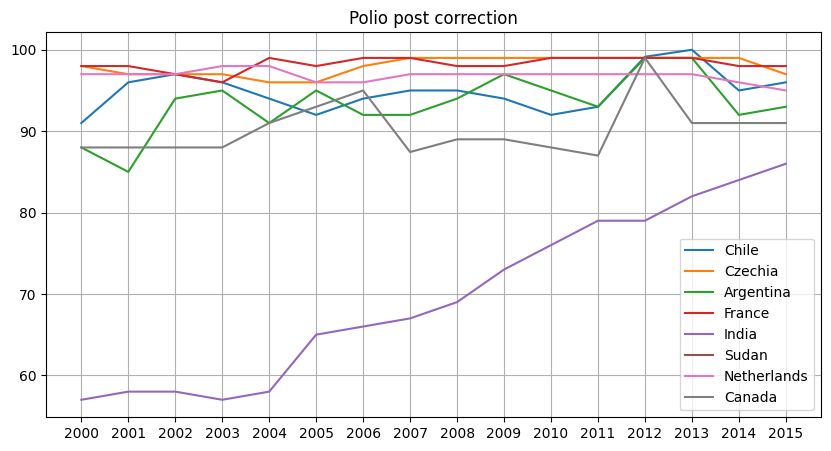

In [313]:
data = process_column(data,
    countries,
    "Polio",
    zero_year=1955,
    drop_less_10 = True)

### Diphtheria

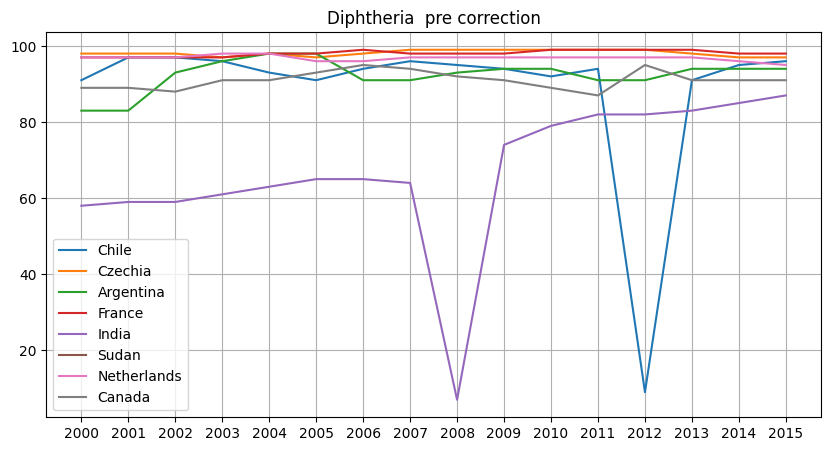

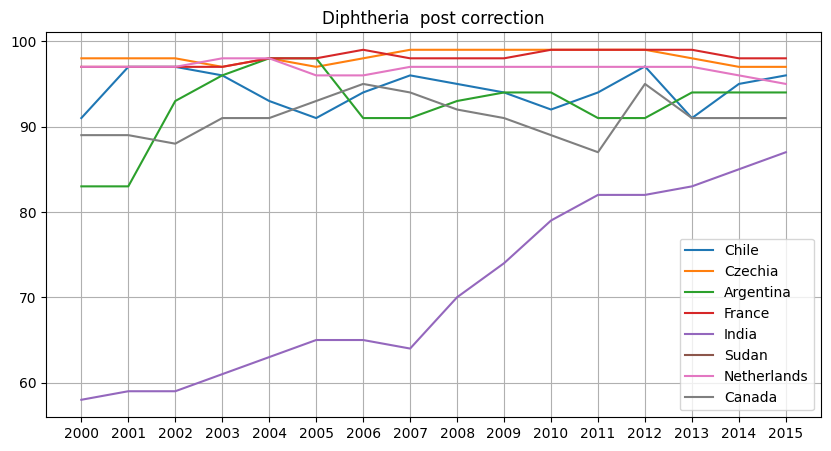

In [314]:
data = process_column(data,
    countries,
    "Diphtheria ",
    zero_year = 1976,
    drop_less_10 = True)

### Total expenditure

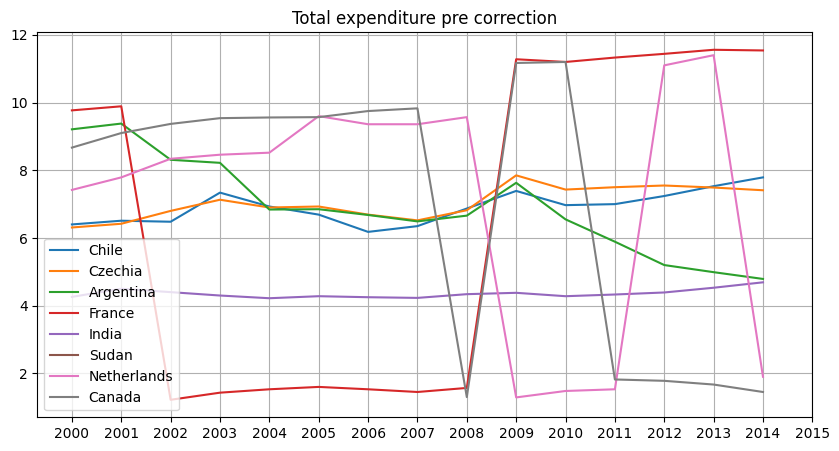

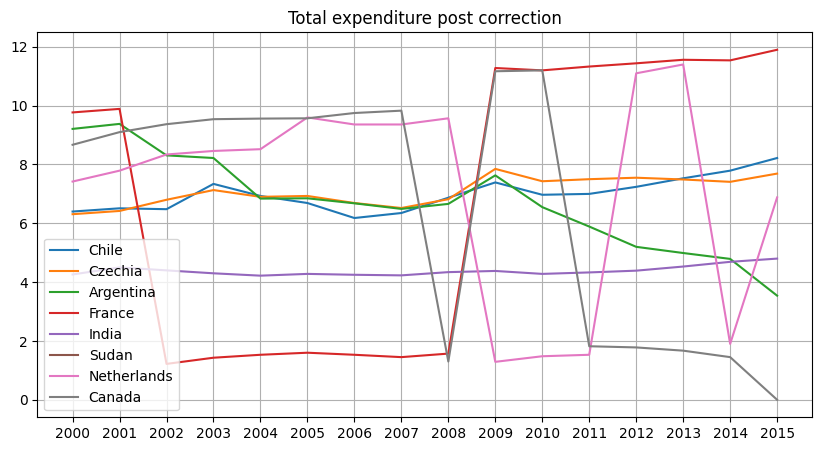

In [315]:
data = process_column(data,
    countries,
    "Total expenditure")

### Other columns

Okey, we still have two columns with null values. We will impute the values based on KNN!

In [316]:

null_columns = data.isna().sum()
null_columns
for col in null_columns.index:
    if null_columns[col] > 0:
        print(col, null_columns[col], "Null values")
        display(pd.DataFrame(data[data[col].isna()].Country.value_counts()))

GDP 406 Null values


,count
Country,
Bahamas,16
Bolivia (Plurinational State of),16
Côte d'Ivoire,16
Congo,16
Czechia,16
Democratic Republic of the Congo,16
Egypt,16
Gambia,16
Iran (Islamic Republic of),16


Population 612 Null values


,count
Country,
Antigua and Barbuda,16
Bahamas,16
Bahrain,16
Barbados,16
Bolivia (Plurinational State of),16
Brunei Darussalam,16
Côte d'Ivoire,16
Congo,16
Cuba,16


Income composition of resources 128 Null values


,count
Country,
Côte d'Ivoire,16
Czechia,16
Democratic Republic of the Congo,16
Republic of Korea,16
Republic of Moldova,16
United Kingdom of Great Britain and Northern Ireland,16
United Republic of Tanzania,16
United States of America,16


Schooling 128 Null values


,count
Country,
Côte d'Ivoire,16
Czechia,16
Democratic Republic of the Congo,16
Republic of Korea,16
Republic of Moldova,16
United Kingdom of Great Britain and Northern Ireland,16
United Republic of Tanzania,16
United States of America,16


In [317]:
data = data.drop(
    columns=["index", "null_values"])

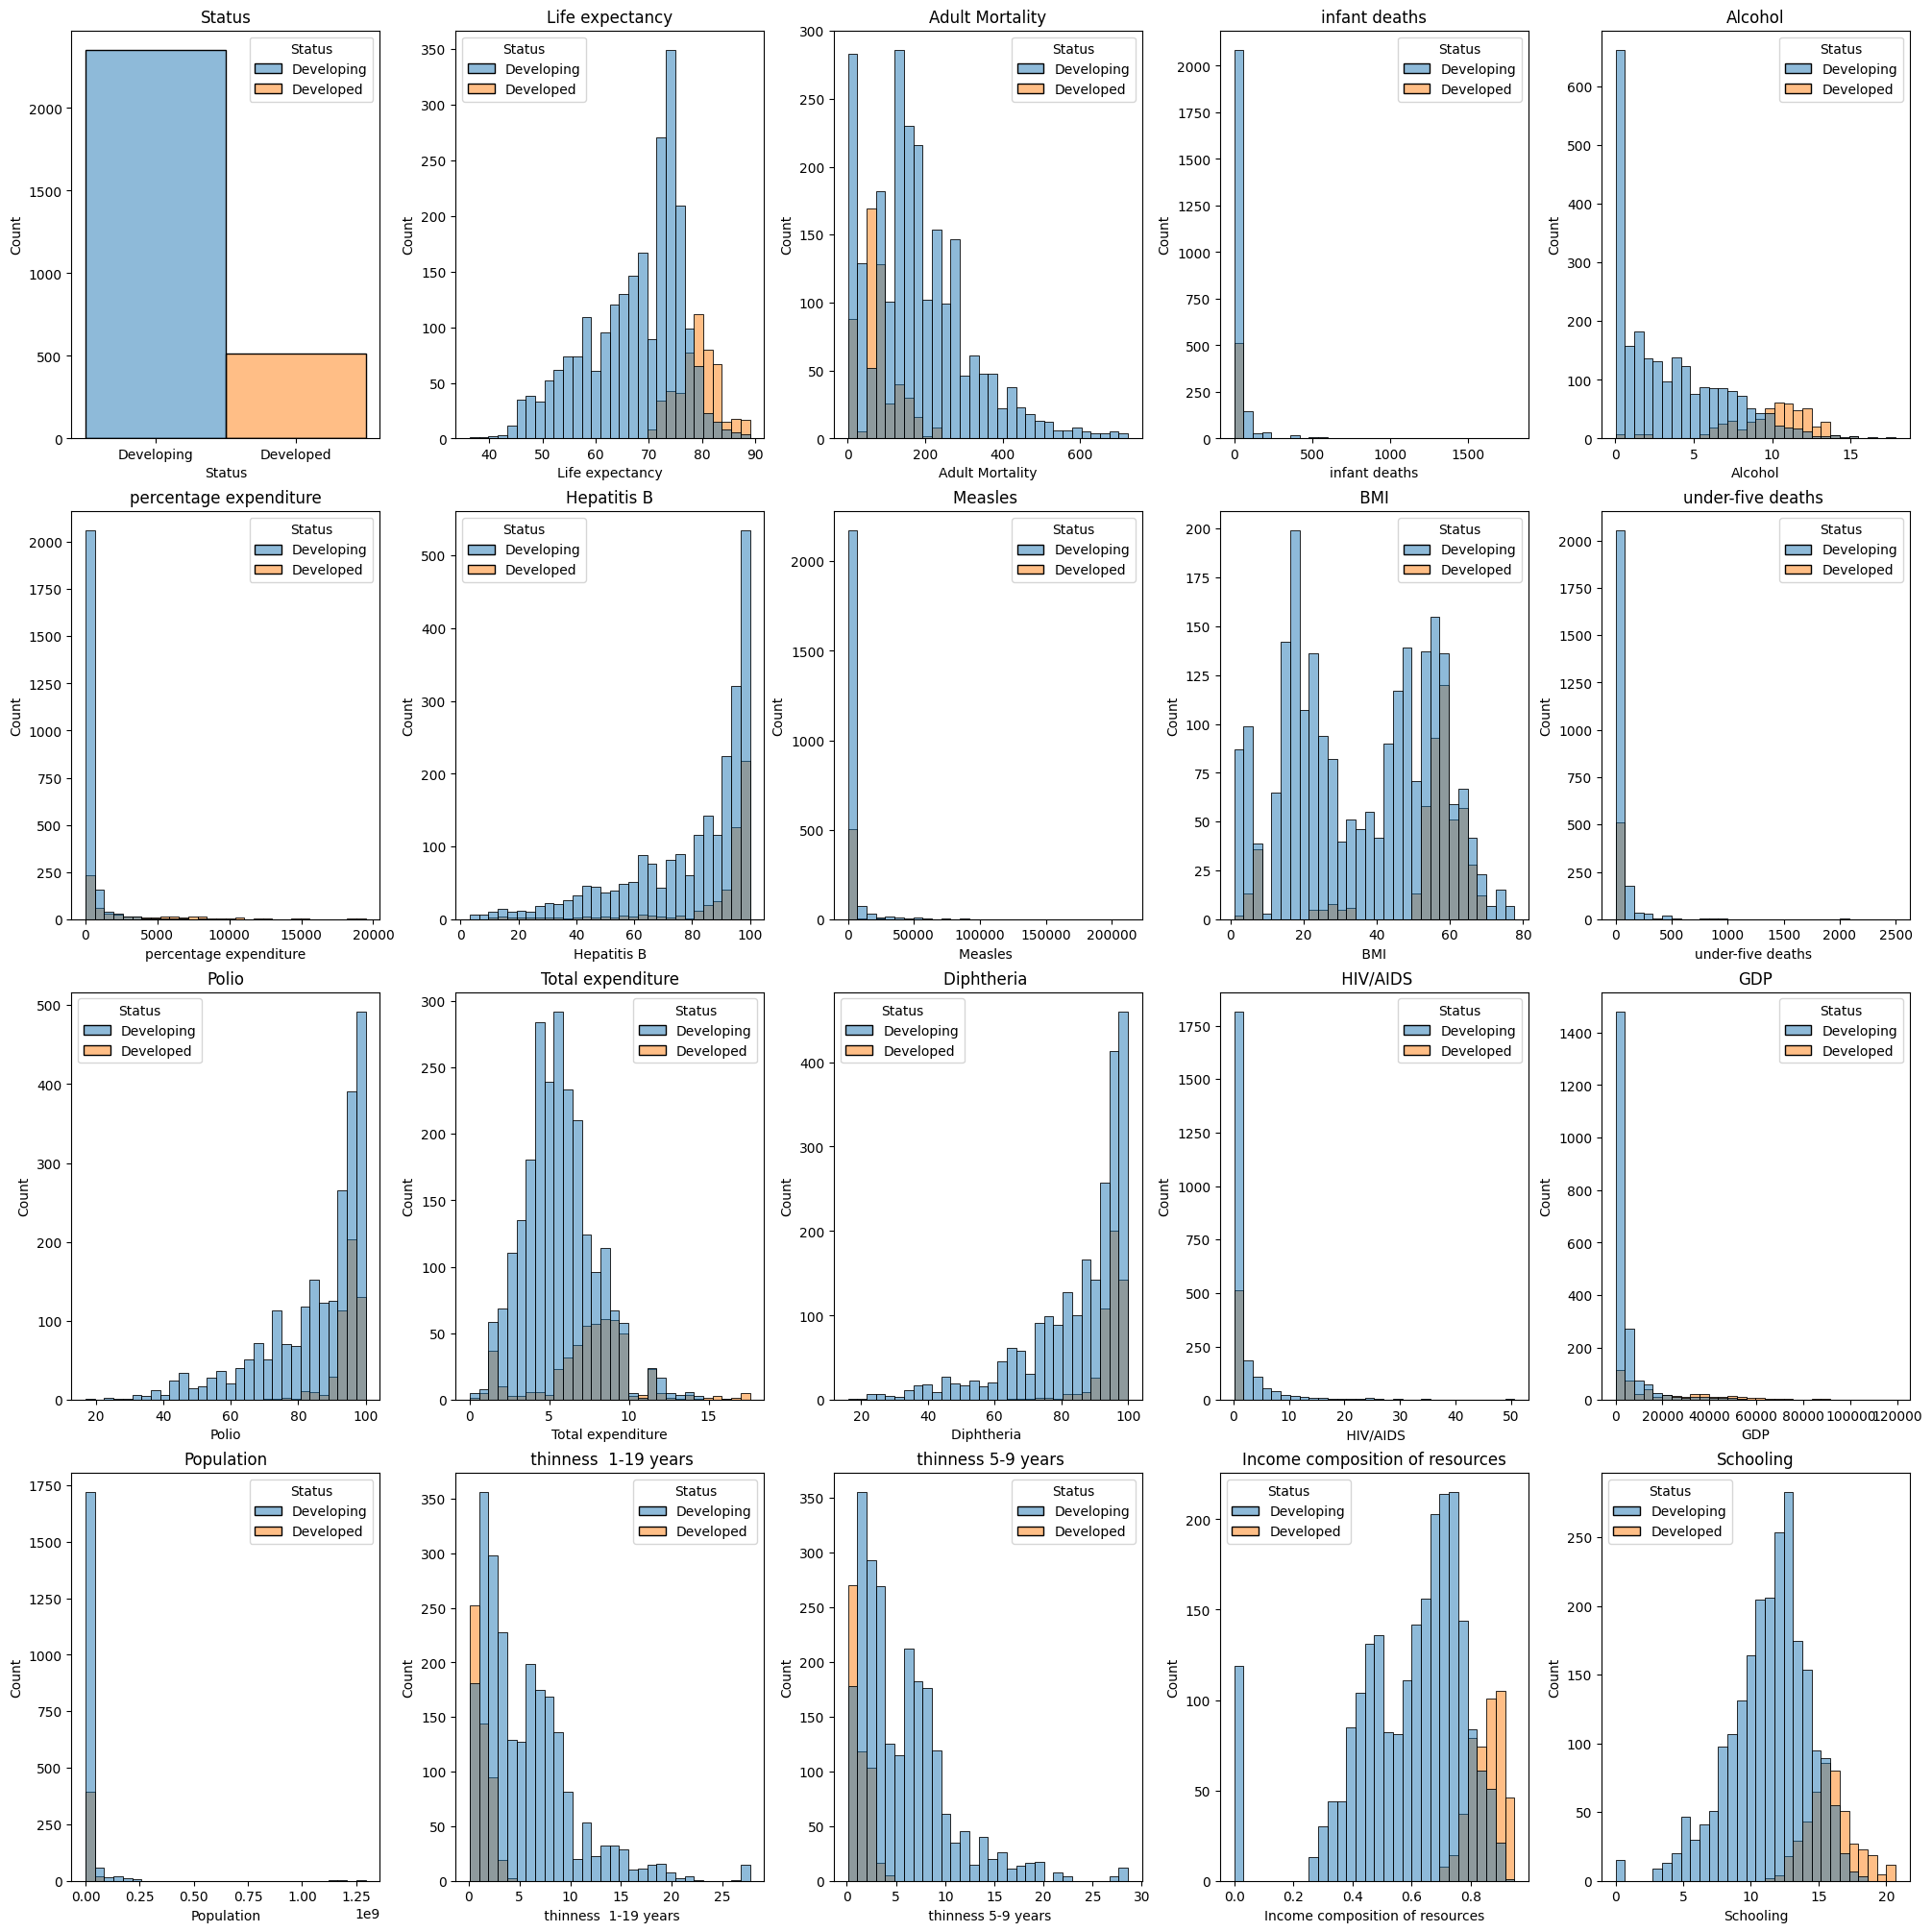

In [318]:
fig, axes = plt.subplots(4, 5, figsize=(20, 20), constrained_layout=True)
columns_to_plot = [a for a in data.columns if a not in ["Country", "Year"]]
for index, column in enumerate(columns_to_plot):
    sns.histplot(data, x = column, hue = data["Status"], bins=30, ax=axes[index//5, index%5])
    axes[index//5, index%5].set_title(column)
plt.show()

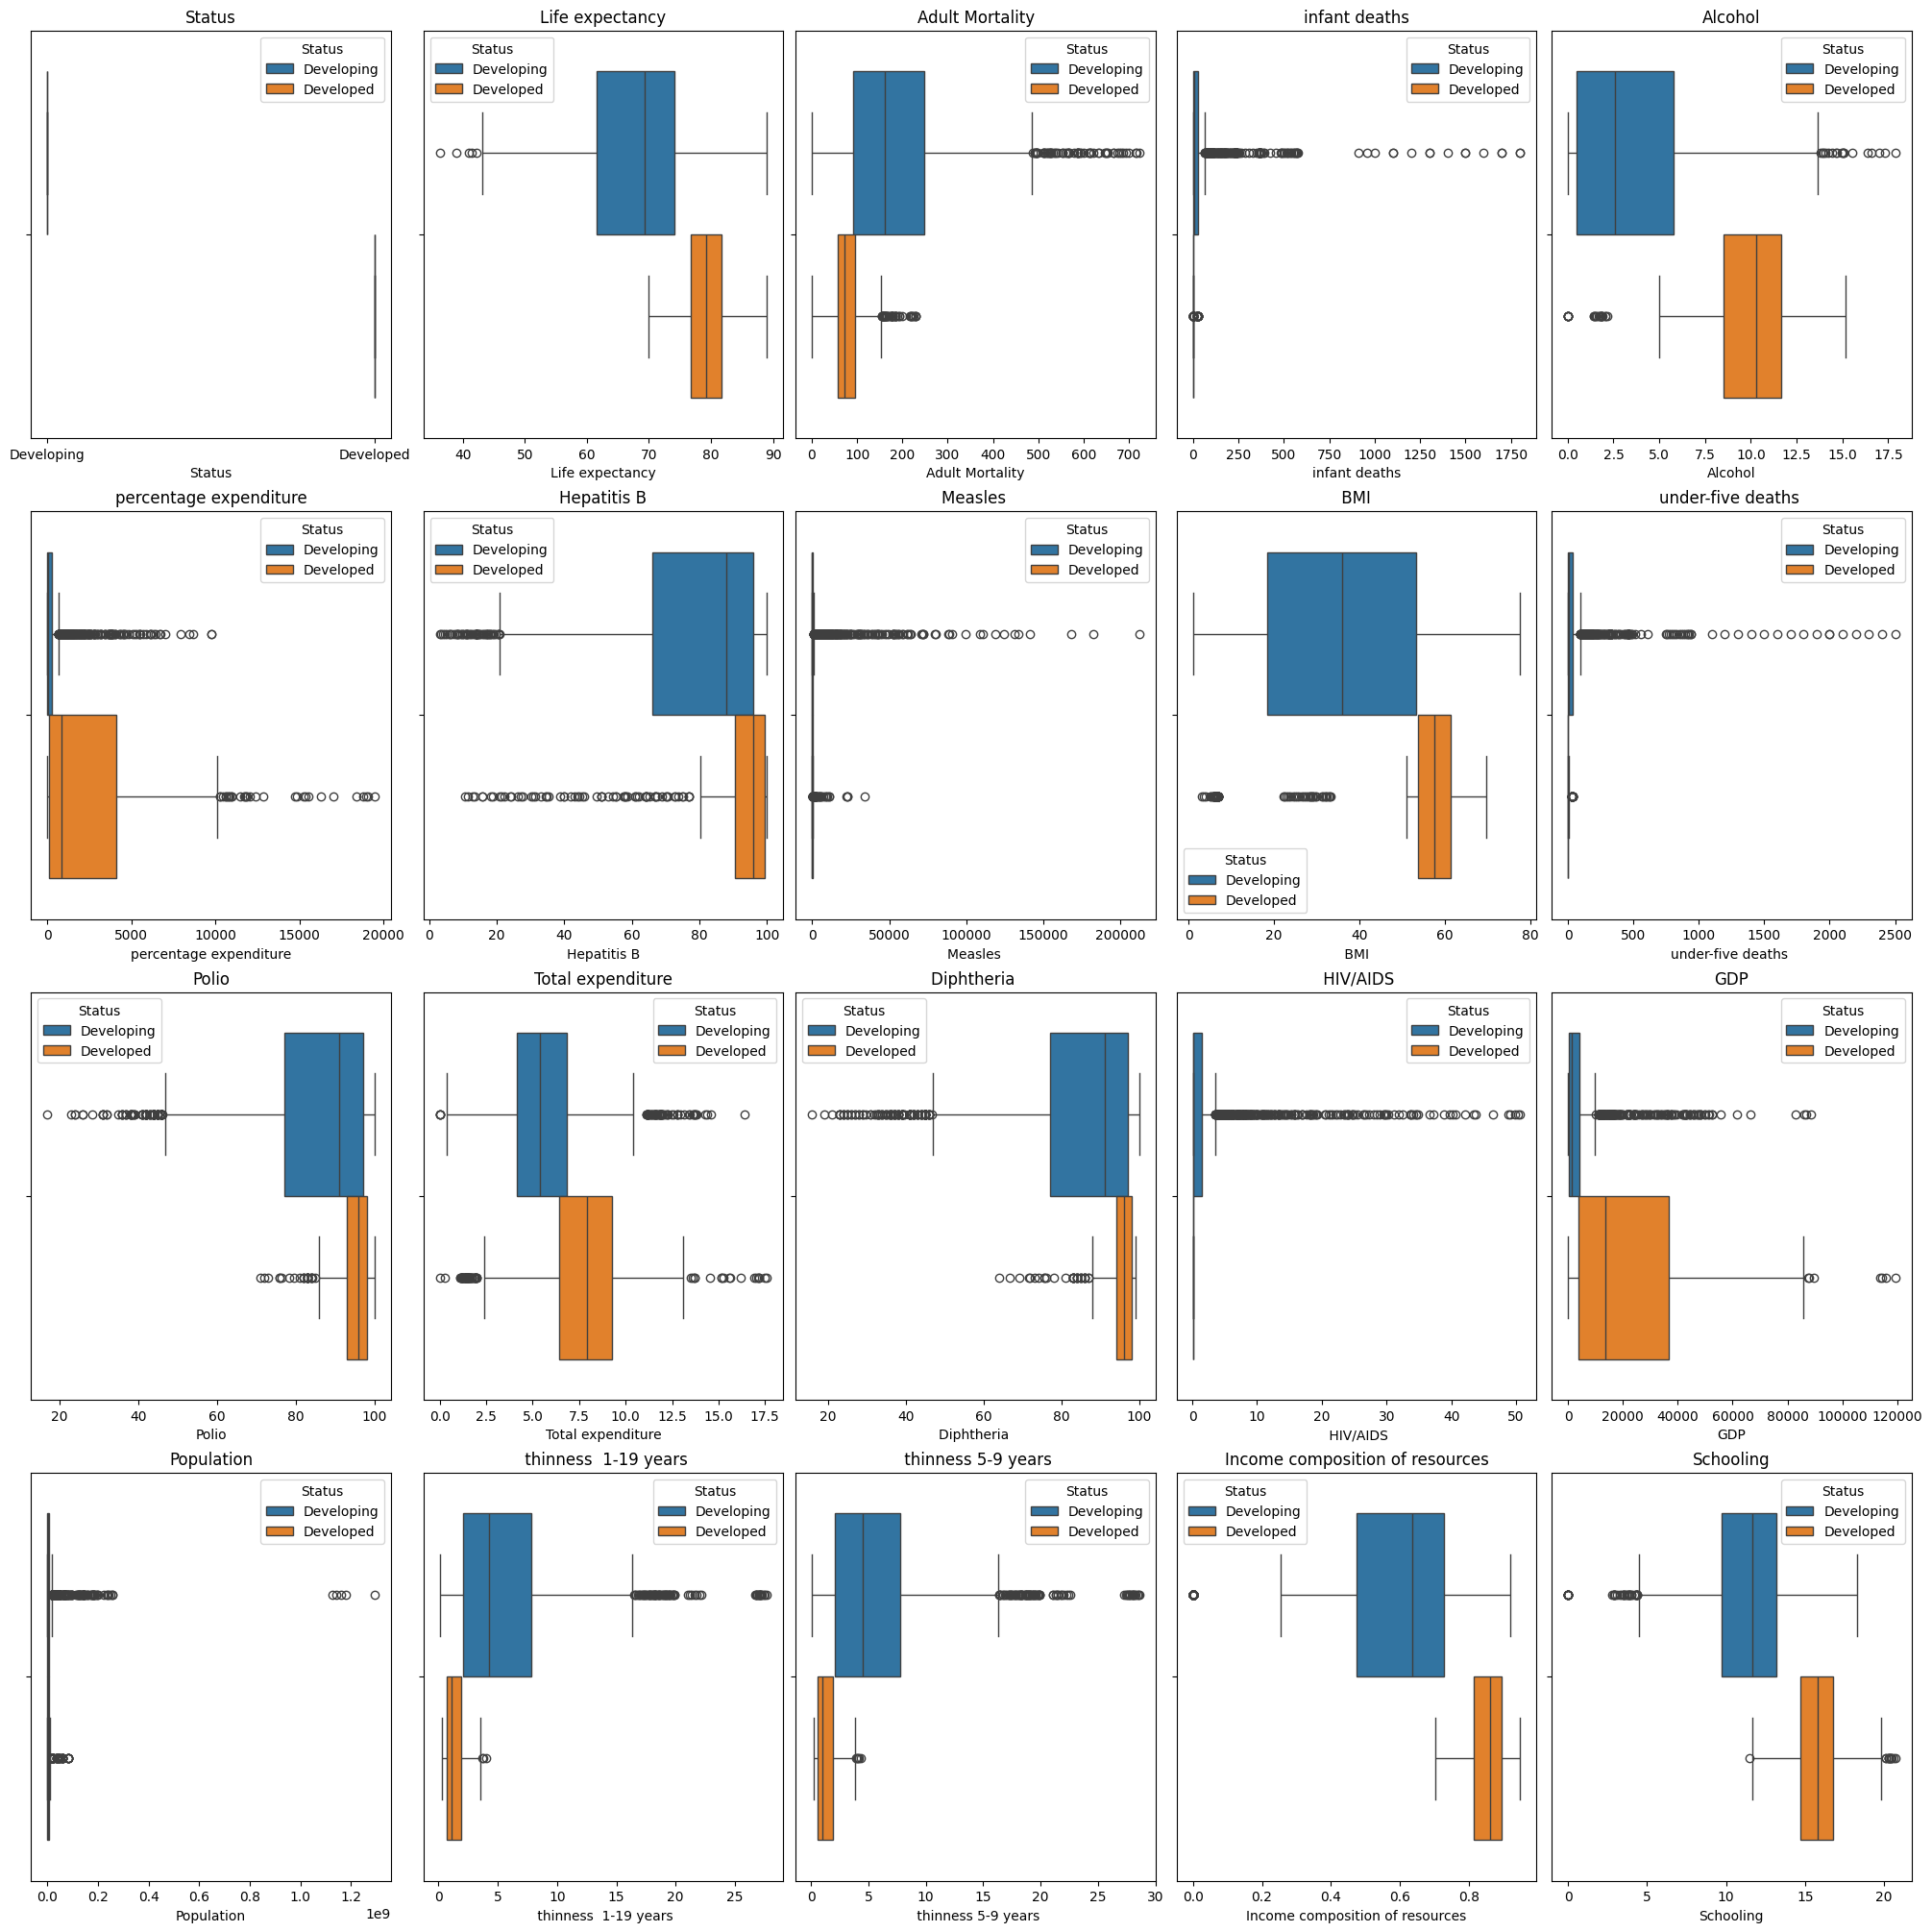

In [319]:
fig, axes = plt.subplots(4, 5, figsize=(20, 20), constrained_layout=True)
for index, column in enumerate(columns_to_plot):
    sns.boxplot(data, x = column, hue = data["Status"], ax=axes[index//5, index%5])
    axes[index//5, index%5].set_title(column)
plt.show()

<Axes: >

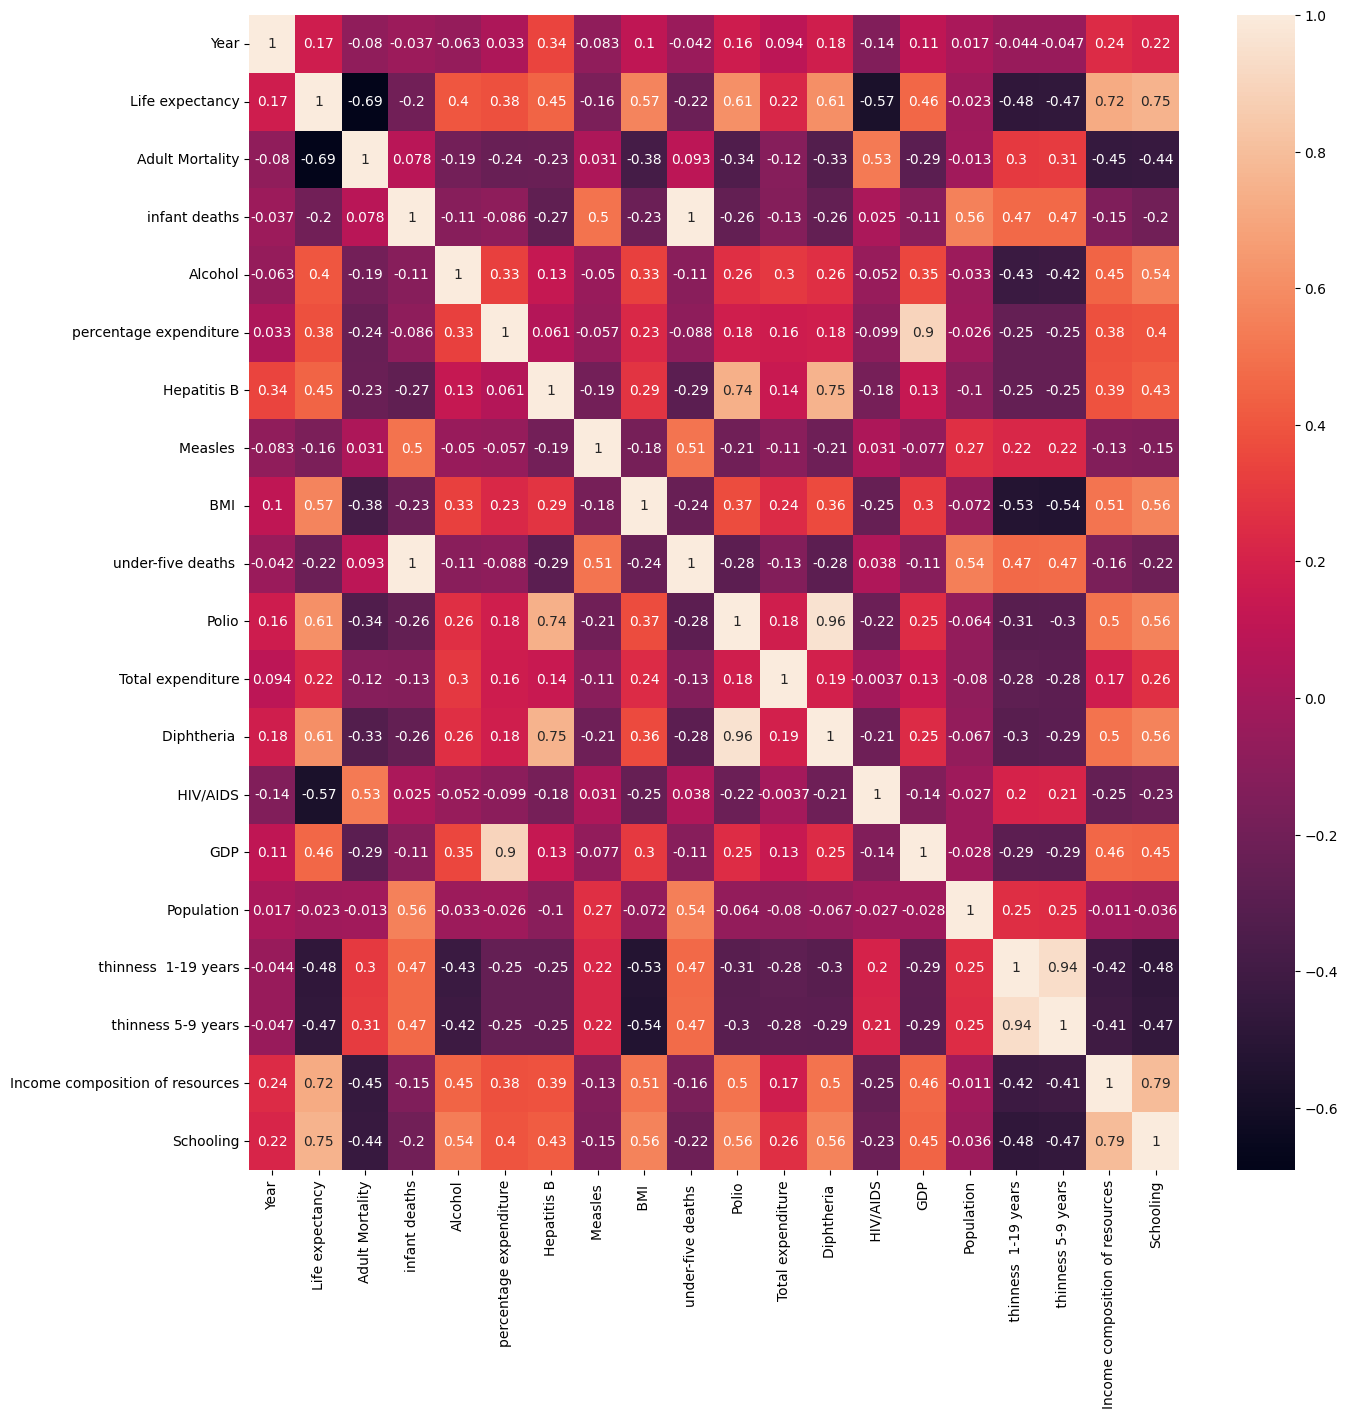

In [320]:
plt.figure(figsize=(15,15))
sns.heatmap(data.drop(columns=["Country", "Status"]).corr(), annot=True)

In [321]:
data = data.drop(columns=["Status"])
data

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,65.0,263,62,0.01,71.279624,65.00,1154,19.1,...,74.15,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,59.9,271,64,0.01,73.523582,62.00,492,18.6,...,58.00,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,59.9,268,66,0.01,73.219243,64.00,430,18.1,...,62.00,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,59.5,272,69,0.01,78.184215,67.00,2787,17.6,...,67.00,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,59.2,275,71,0.01,7.097109,68.00,3013,17.2,...,68.00,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,Zimbabwe,2004,44.3,723,27,4.36,0.000000,68.00,31,27.1,...,67.00,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2860,Zimbabwe,2003,44.5,715,26,4.06,0.000000,63.73,998,26.7,...,68.08,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2861,Zimbabwe,2002,44.8,73,25,4.43,0.000000,73.00,304,26.3,...,73.00,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2862,Zimbabwe,2001,45.3,686,25,1.72,0.000000,76.00,529,25.9,...,76.00,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


We will use a rolling mean to give more robustness to the data

In [322]:
data_countries = data["Country"].unique()

countries_train, countries_test = train_test_split(data_countries, test_size=0.2, random_state=42)

train = data[data["Country"].isin(countries_train)]
test = data[data["Country"].isin(countries_test)]


X_train = train.drop(columns=["Life expectancy", "Country"])
X_train_countries = train["Country"]
y_train = train["Life expectancy"]

X_test = test.drop(columns=["Life expectancy", "Country"])
X_test_countries = test["Country"]
y_test = test["Life expectancy"]


In [ ]:


cv = GroupKFold(n_splits=5)
splits = cv.split(X_train, y_train, groups=X_train_countries)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5)),
    ("poly", PolynomialFeatures()),
    ("model", ElasticNet())
])
parameters = {
    "poly__degree": [1, 2, 3],
    "model__alpha": [0.01, 0.1, 1],
    "model__l1_ratio": [0.1, 0.5, 0.9]
}
grid_search = GridSearchCV(pipeline, parameters, cv=splits, n_jobs=5)
grid_search.fit(X_train, y_train)

display(grid_search.best_params_)
display(grid_search.best_score_)
display(grid_search.best_estimator_)

{'model__alpha': 0.1, 'model__l1_ratio': 0.9, 'poly__degree': 2}

np.float64(0.8522004322014378)

Pipeline(steps=[('scaler', StandardScaler()), ('imputer', KNNImputer()),
                ('poly', PolynomialFeatures()),
                ('model', ElasticNet(alpha=0.1, l1_ratio=0.9))])

In [338]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__alpha,param_model__l1_ratio,param_poly__degree,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.105557,0.006766,0.021991,0.007670,0.01,0.1,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",0.837587,0.774138,0.773098,0.782055,0.844773,0.802330,0.031953,5
1,0.308364,0.029755,0.023741,0.010944,0.01,0.1,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",0.850340,0.839793,0.780149,0.787413,-3.058812,0.039777,1.549542,18
2,2.847756,0.094310,0.032305,0.009021,0.01,0.1,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.1,...",0.346986,0.764555,0.752814,0.772902,-48.128605,-9.098270,19.515835,26
3,0.084538,0.009712,0.024431,0.009201,0.01,0.5,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",0.838640,0.775028,0.773074,0.782048,0.847600,0.803278,0.032790,4
4,0.312537,0.036024,0.025745,0.011714,0.01,0.5,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",0.863526,0.843729,0.790630,0.794995,-3.031031,0.052370,1.541954,17
5,2.489223,0.120416,0.037486,0.011781,0.01,0.5,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.5,...",0.462374,0.839917,0.787125,0.827190,-28.979051,-5.212489,11.884092,24
6,0.098558,0.019112,0.026368,0.011906,0.01,0.9,1,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",0.843058,0.777511,0.773820,0.782191,0.853127,0.805942,0.034665,3
7,0.335836,0.016932,0.027126,0.009481,0.01,0.9,2,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",0.869838,0.847658,0.797549,0.800288,-2.621808,0.138705,1.380534,16
8,2.515918,0.071660,0.039210,0.011384,0.01,0.9,3,"{'model__alpha': 0.01, 'model__l1_ratio': 0.9,...",0.599843,0.871972,0.803956,0.847320,-62.936805,-11.962743,25.487212,27
9,0.090246,0.005778,0.029735,0.013628,0.10,0.1,1,"{'model__alpha': 0.1, 'model__l1_ratio': 0.1, ...",0.831026,0.778392,0.773306,0.792038,0.810563,0.797065,0.021326,6


In [ ]:
cv_results[cv_results.rank_test_score == 1][["mean_test_score", "std_test_score"]]

,mean_test_score,std_test_score
16,0.8522,0.026512


## Metrics

In [332]:
pipeline = grid_search.best_estimator_
y_pred = pipeline.predict(X_test)
r2 = pipeline.score(X_test, y_test)
r = np.sqrt(r2)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"R2: {r2}")
print(f"Pearson (r): {r}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

R2: 0.8978875894125847
Pearson (r): 0.947569305862418
MSE: 10.31582867100996
RMSE: 3.211826376224275


In [345]:
X_test_countries

144                                            Azerbaijan
145                                            Azerbaijan
146                                            Azerbaijan
147                                            Azerbaijan
148                                            Azerbaijan
                              ...                        
2699    United Kingdom of Great Britain and Northern I...
2700    United Kingdom of Great Britain and Northern I...
2701    United Kingdom of Great Britain and Northern I...
2702    United Kingdom of Great Britain and Northern I...
2703    United Kingdom of Great Britain and Northern I...
Name: Country, Length: 576, dtype: object

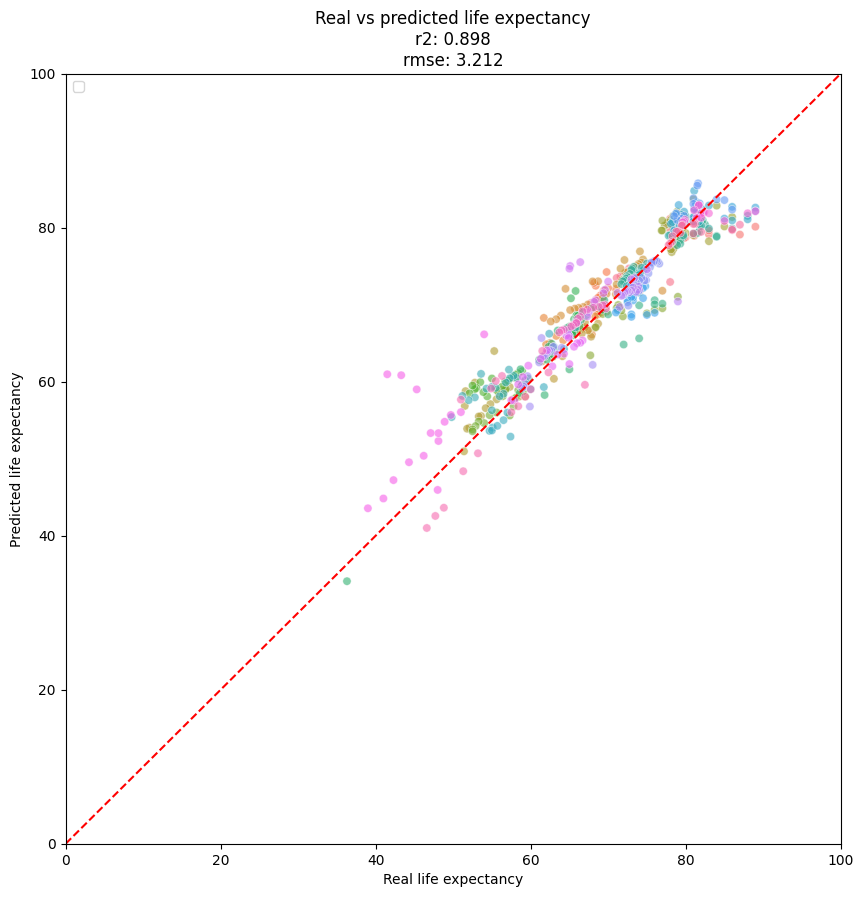

In [352]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.scatterplot(x = y_test, y = y_pred, alpha=0.6, hue=X_test_countries)
ax.set_xlabel("Real life expectancy")
ax.set_ylabel("Predicted life expectancy")
ax.set_title(f"Real vs predicted life expectancy\nr2: {round(r2, 3)}\nrmse: {round(rmse, 3)}")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.plot([0, 100], [0, 100], "--", color="red")
ax.legend([])
plt.show()

## Coefficients analysis 

In [326]:
coefs = pd.DataFrame(pipeline.named_steps["model"].sparse_coef_.toarray()).T
coefs = coefs.rename(columns={0: "coef"})
coefs["feature_names"] = pipeline.named_steps["poly"].get_feature_names_out(
    input_features = X_train.columns)

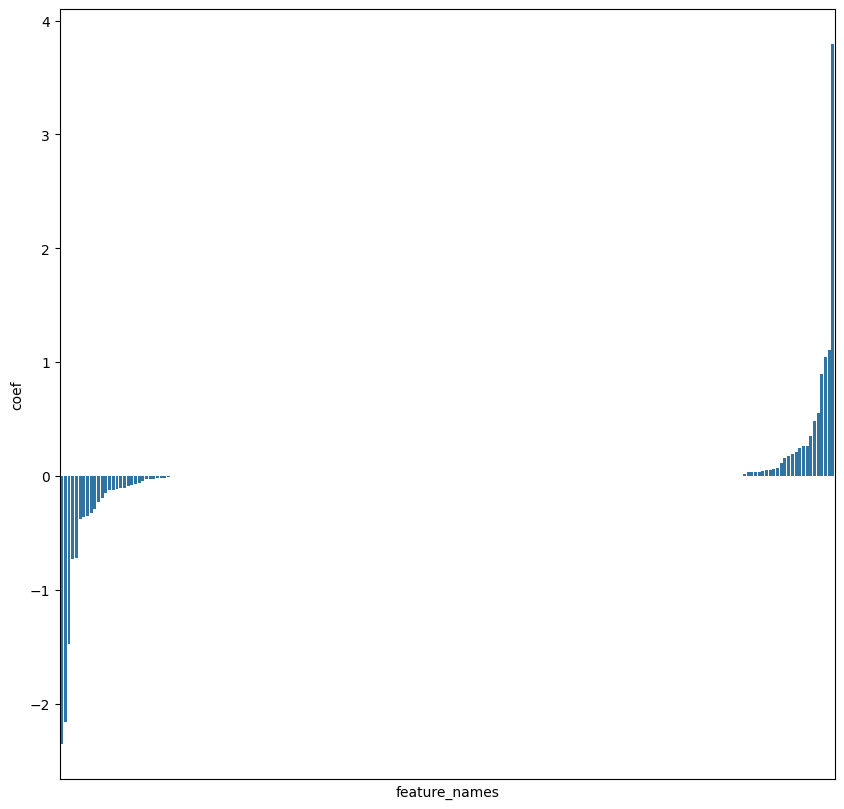

In [327]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(coefs.sort_values(by="coef"), x = "feature_names", y = "coef", axes=ax)
ax.set_xticks([])
plt.show()

In [328]:
coefs["abs_coef"] = coefs.coef.abs()
most_important = coefs.sort_values(by="abs_coef", ascending=False)[:20]

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_23052\3555459872.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(most_important.feature_names, rotation=90)


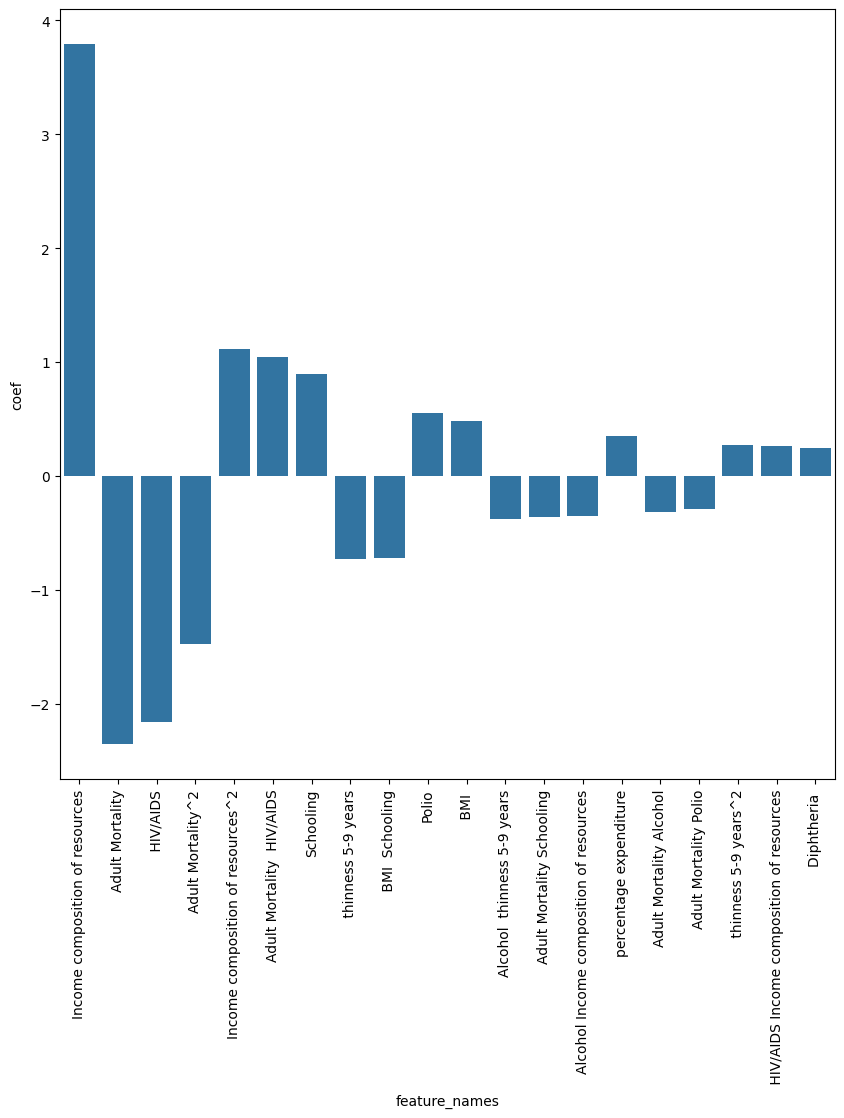

In [329]:
fig, ax = plt.subplots(figsize=(10,10))
ax = sns.barplot(most_important, x = "feature_names", y = "coef", axes=ax)
ax.set_xticklabels(most_important.feature_names, rotation=90)
plt.show()